#### Libraries

In [30]:
import re
import requests
import pandas as pd
from datetime import datetime
from google.oauth2 import service_account
from googleapiclient.discovery import build
import gspread
from google.oauth2.service_account import Credentials
from gspread_formatting import format_cell_ranges, CellFormat, Color
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import openpyxl as px

### API

This creates a modular client (frontend) call that is able to extract the desired subset of data from the API server (backend); -and, make it easily reusable for future queries.


In [31]:
# Path to your service account key file
SERVICE_ACCOUNT_FILE = '/home/lfvm/Desktop/codebaker/nyckelring/brelok/summer-sector-439022-v6-2eafffbbfb90.json' # Update with the actual path or team credentials file

# VERY IMPORTANT: Ensure the service account has access to the Google Sheet by sharing it with the service account email

# Original Google Sheet ID (latest version) 
ORIGINAL_SPREADSHEET_ID =  '1t61MafCmnRe2QN082Bk1V0IxBSIW8UUqH1g5mULgb2o'

# Define the sheet tab or range to read
RANGE_NAME = 'db-test'


# Define scopes for Google Sheets and Drive API
SCOPES = ['https://www.googleapis.com/auth/spreadsheets', 
          'https://www.googleapis.com/auth/drive']

In [32]:
# Authenticate and build both Sheets and Drive services
creds = service_account.Credentials.from_service_account_file(
    SERVICE_ACCOUNT_FILE, scopes=SCOPES)
sheet_service = build('sheets', 'v4', credentials=creds)
drive_service = build('drive', 'v3', credentials=creds)

### Import Data

In [33]:
# Loading data as df
 
# Call the Sheets API to read data
sheet = sheet_service.spreadsheets()
result = sheet.values().get(spreadsheetId=ORIGINAL_SPREADSHEET_ID, range=RANGE_NAME).execute()
values = result.get('values', [])

# Convert to DataFrame for easier manipulation
df = pd.DataFrame(values[1:], columns=values[0])
print(df.head()) 

  event_type   time_unit      date_1 date_2  year month day duration  \
0    Seizure  Individual  2025-03-24         2025     3  24            
1    Seizure  Individual  2025-03-23         2025     3  23            
2    Seizure  Individual  2025-03-22         2025     3  22            
3    Seizure  Individual  2025-03-22         2025     3  22            
4    Seizure  Individual  2025-03-19         2025     3  19            

                        drug_type quantity  ...  \
0                         Cocaine       10  ...   
1                         Cocaine      2.5  ...   
2                         Cocaine     2619  ...   
3  Other (explain in Description)     1240  ...   
4                         Cocaine    16.05  ...   

  destination_1_department/state destination_1_municipality/port  \
0                                                                  
1                                                         Madrid   
2                                                       

### Pre-process

In [34]:
# Handle Missing/Invalid Values. We want to keep this step as simple as possible, as we will be changing the data structure later.
 
df = df.replace('', pd.NA)  # Convert empty strings to NA
df = df.replace(r'^\s*$', pd.NA, regex=True)  # Convert whitespace to NA
print("✓ Converted empty strings/whitespace to NA values")

✓ Converted empty strings/whitespace to NA values


In [35]:
# Indentify Existing Dropdowns
 
def get_sheet_dropdowns(spreadsheet_id, sheet_name, creds):
    service = build('sheets', 'v4', credentials=creds)
    sheet_metadata = service.spreadsheets().get(
        spreadsheetId=spreadsheet_id,
        ranges=[sheet_name],
        includeGridData=True
    ).execute()

    dropdowns_by_column = {}

    for sheet in sheet_metadata['sheets']:
        if sheet['properties']['title'] != sheet_name:
            continue

        col_dropdowns = {}
        rows = sheet['data'][0]['rowData']
        header_row = rows[0]['values']
        col_names = [cell.get('formattedValue', f"Column_{i}") for i, cell in enumerate(header_row)]

        for col_idx, col_name in enumerate(col_names):
            dropdowns_in_col = set()
            for row in rows[1:]:  # Skip header
                cell = row['values'][col_idx]
                if 'dataValidation' in cell:
                    dv = cell['dataValidation']
                    if dv['condition']['type'] == 'ONE_OF_LIST':
                        values = [v['userEnteredValue'] for v in dv['condition']['values']]
                        dropdowns_in_col.update(values)
            if dropdowns_in_col:
                col_dropdowns[col_name] = list(dropdowns_in_col)

        dropdowns_by_column.update(col_dropdowns)

    return dropdowns_by_column

dropdown_options = get_sheet_dropdowns(ORIGINAL_SPREADSHEET_ID, RANGE_NAME, creds)

# Print results
for col, options in dropdown_options.items():
    print(f"🔽 {col}: {options}")


🔽 event_type: ['Seizure', 'Price', 'Crop Eradication', 'Total Production Estimate', 'Total Crop Cultivation Estimate', 'Other (explain in Description)']
🔽 time_unit: ['Multi-Month', 'Multi-Year', 'Year', 'Individual', 'Month', 'Other (explain in Description)']
🔽 drug_type: ['Coca Crops', 'Cocaine', 'Cocaine - Crack', 'Cocaine Base', 'Other (explain in Description)', 'All/Unspecified/Multiple']
🔽 weight_unit: ['Euro', 'Hectare', 'Package', 'Pounds (£)', 'Percent', 'Kilogram', 'Pounds (lbs)', 'Other currency (say which in Description)', 'Other (explain in Description)', 'USD', 'Plant']
🔽 modus_operandi/place_seizure: ['Container', 'Air', 'Maritime vessel', 'Land', 'River vessel']
🔽 region: ['Caribbean', 'Oceania', 'Europe', 'Central America', 'Global', 'North America', 'Asia', 'South America', 'Africa']
🔽 country: ['Papua new Guinea', 'Liechtenstein', 'Latvia', 'Madagascar', 'Burundi', 'Mexico', 'Cambodia', 'Senegal', 'Yemen', 'Trinidad And Tobago', 'Togo', 'Philippines', 'China', 'Korea

## Monitoring

##### Summary Stats

In [36]:
def get_dataframe_summary(df):
    
    # --- General DataFrame Info ---
    general_info = {
        "Shape": f"{df.shape[0]} rows × {df.shape[1]} cols",
        "Memory Usage": f"{df.memory_usage(deep=True).sum() / (1024 ** 2):.2f} MB",
        "Columns with NA": f"{df.isna().any().sum()} / {len(df.columns)}",
        "Duplicate Rows": f"{df.duplicated().sum()} ({(df.duplicated().mean() * 100):.1f}%)",
        "Numeric Columns": f"{df.select_dtypes(include='number').shape[1]}",
        "Categorical Columns": f"{df.select_dtypes(include=['object', 'category']).shape[1]}",
        "Datetime Columns": f"{df.select_dtypes(include='datetime').shape[1]}"
    }

    # --- Compute dropdown options per column ---
    dropdown_options_dict = {
        col: dropdown_options.get(col, [])
        for col in df.columns
    }
    
    # --- Column-Level Stats ---
    column_stats = pd.DataFrame({
        'Variable': df.columns,
        'Dtype': df.dtypes.values,
        'Unique_Count': df.nunique().values,
        'NA_Count': df.isna().sum().values,
        'NA_Percentage': (df.isna().mean() * 100).round(1).values,
        'Duplicate_Count': df.apply(lambda col: col.duplicated(keep=False).sum()).values,
        'Duplicate_Percentage': (df.apply(lambda col: col.duplicated(keep=False).mean()) * 100).round(1).values,
        'Unique_Values': df.apply(lambda x: x.drop_duplicates().tolist()).values,
        'Dropdown_Options': [dropdown_options_dict[col] for col in df.columns],
        'Dropdown_Option_Count': [len(dropdown_options_dict[col]) for col in df.columns]
    }).sort_values('Unique_Count', ascending=False)


    # --- Format percentages ---
    column_stats['NA_Percentage'] = column_stats['NA_Percentage'].astype(str) + '%'
    column_stats['Duplicate_Percentage'] = column_stats['Duplicate_Percentage'].astype(str) + '%'

    return general_info, column_stats

# Run the summary
general_info, column_stats = get_dataframe_summary(df)

# Print General Info
print("=== GENERAL DATAFRAME INFO ===")
for key, value in general_info.items():
    print(f"{key}: {value}")

# Display Column Stats (including dropdown options)
print("\n=== COLUMN-LEVEL STATISTICS ===")
display(column_stats)


=== GENERAL DATAFRAME INFO ===
Shape: 654 rows × 41 cols
Memory Usage: 1.66 MB
Columns with NA: 33 / 41
Duplicate Rows: 0 (0.0%)
Numeric Columns: 0
Categorical Columns: 41
Datetime Columns: 0

=== COLUMN-LEVEL STATISTICS ===


,Variable,Dtype,Unique_Count,NA_Count,NA_Percentage,Duplicate_Count,Duplicate_Percentage,Unique_Values,Dropdown_Options,Dropdown_Option_Count
35,description,object,649,2,0.3%,8,1.2%,"[Spanish citizen, coming from Lisbon , was sto...",[],0
39,source_link,object,629,0,0.0%,46,7.0%,[https://www.lanazione.it/firenze/cronaca/coca...,[],0
9,quantity,object,401,3,0.5%,359,54.9%,"[10, 2.5, 2619, 1240, 16.05, 65, 6600, 142, 55...",[],0
17,municipality/port,object,398,155,23.7%,312,47.7%,"[Florence, Santo Domingo, Lake Maracaibo , Eag...",[],0
11,seizure_kg,object,330,149,22.8%,411,62.8%,"[9., 2.5, 2,619., 1,240., 16.05, 65., 6,600., ...",[],0
16,department/state,object,292,61,9.3%,469,71.7%,"[<NA>, Zulia, Texas, Cáceres, Azores, Québec, ...",[],0
2,date_1,object,146,0,0.0%,628,96.0%,"[2025-03-24, 2025-03-23, 2025-03-22, 2025-03-1...",[],0
13,sub_modus_operandi,object,106,546,83.5%,550,84.1%,"[Liquid cocaine, <NA>, Production laboratory, ...",[],0
24,transit_1_municipality/port,object,91,543,83.0%,579,88.5%,"[<NA>, Matapalo, Rio de Janeiro, Acapulco, Kin...",[],0
23,transit_1_department/state,object,74,527,80.6%,598,91.4%,"[Lisbon, <NA>, Santo Domingo, Paris, Puntarena...",[],0


##### Missing Data


Missing values per column:
event_type                           0
time_unit                            0
date_1                               0
date_2                             640
year                                 0
month                                0
day                                  1
duration                           639
drug_type                            0
quantity                             3
weight_unit                          2
seizure_kg                         149
modus_operandi/place_seizure         7
sub_modus_operandi                 546
region                               0
country                              4
department/state                    61
municipality/port                  155
origin_country                     566
origin_area                        627
origin_municipality                639
transit_1_region                   443
transit_1_country                  430
transit_1_department/state         527
transit_1_municipality/port        54

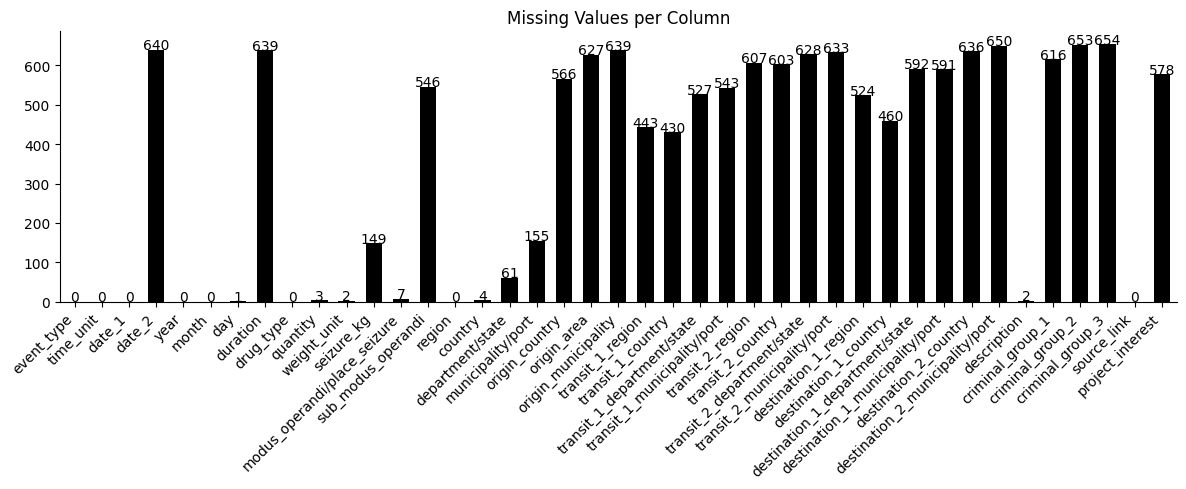

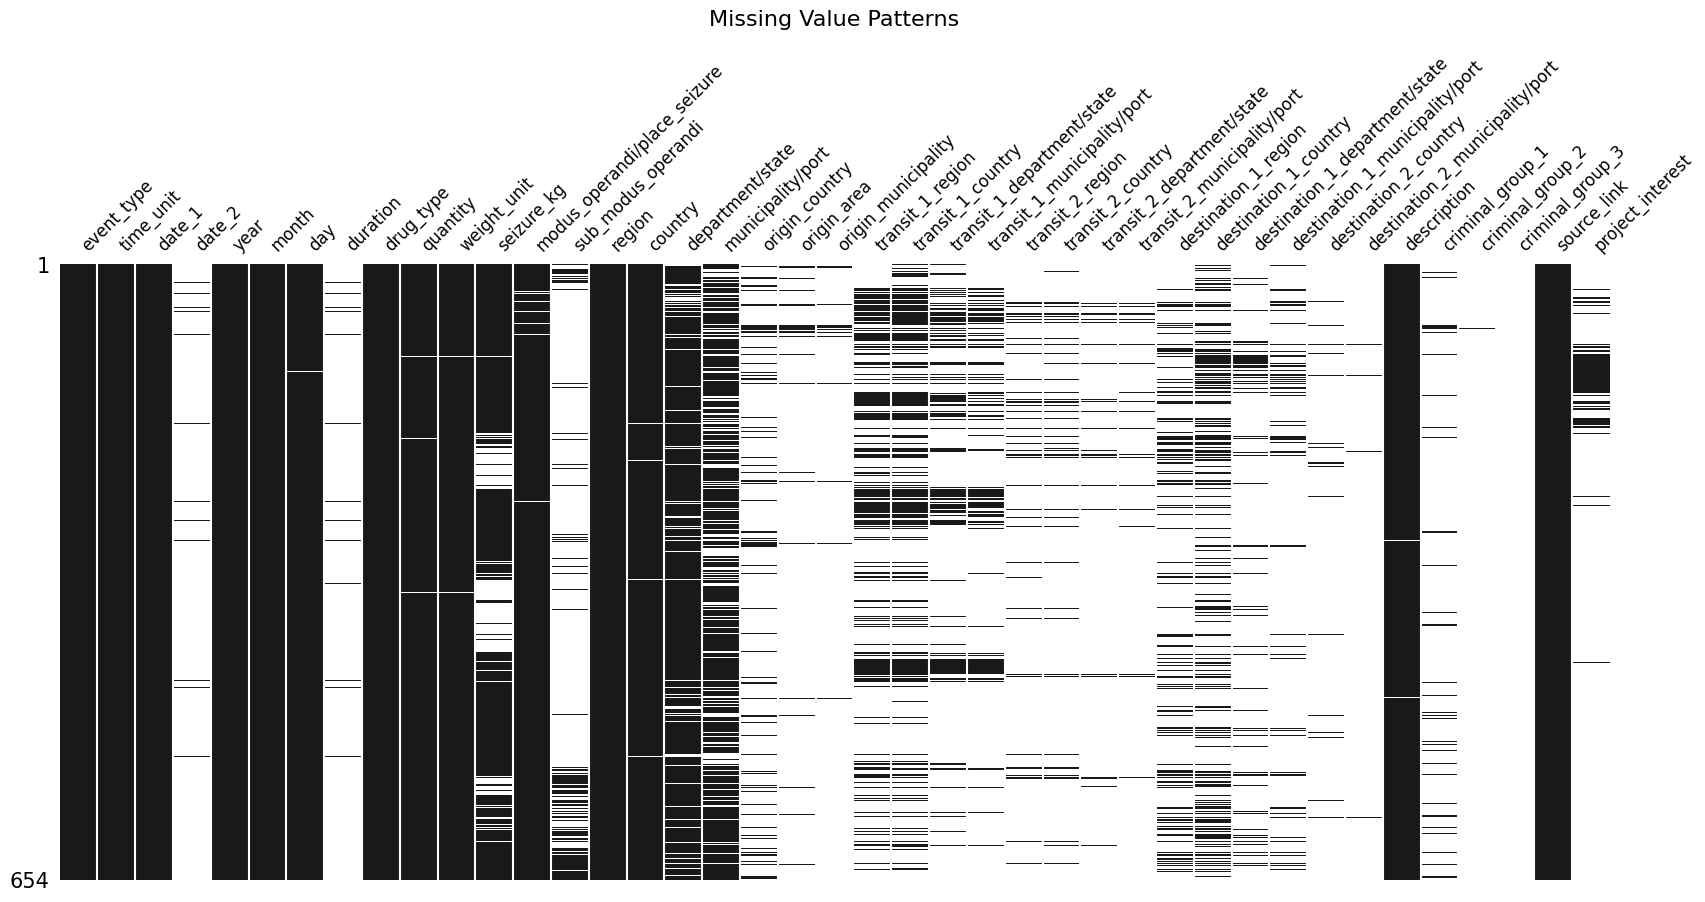

In [37]:

missing_values = df.isnull().sum()
print(f"Missing values per column:\n{missing_values}\n")

# Visualization 1: Bar Chart
plt.figure(figsize=(12, 5))
ax = missing_values.plot(kind='bar', color="#000000", width=0.6)
ax.grid(False)
for i in ax.patches:
    ax.text(i.get_x() + i.get_width()/2, i.get_height()+1, 
            f'{int(i.get_height())}', 
            ha='center', fontsize=10)
plt.xticks(rotation=45, ha='right')
sns.despine()
plt.title("Missing Values per Column")
plt.tight_layout()
plt.show()

# Visualization 2: Missingno Matrix
msno.matrix(
    df,
    figsize=(20, 8),
    color=(0.1, 0.1, 0.1),
    sparkline=False,
    fontsize=12,
    labels=True
)
plt.title("Missing Value Patterns", fontsize=16, pad=20)
plt.show()

## Validation

#### General

##### Column names

In [38]:
# Dictionary mapping old column names to new names
custom_column_names = {
    "Type": "event_type",
    "Time unit": "time_unit",
    "Date": "date_1",
    "Date 2": "date_2",
    "Year": "year",
    "Month": "month",
    "Day": "day",
    "Duration": "duration",
    "Type Drugs": "drug_type",
    "Quantity": "quantity",
    "Weight unit": "weight_unit",
    "seizure_kgs": "seizure_kg",
    "Modus Operandi/place of seizure": "modus_operandi/place_seizure",
    "Sub MO": "sub_modus_operandi",
    "Region": "region",
    "Country": "country",
    "Department/State": "department/state",
    "Municipality/Port": "municipality/port",
    "Origin country": "origin_country",
    "Origin Area": "origin_area",
    "Origin municipality": "origin_municipality",
    "Transit 1/Region": "transit_1_region",
    "Transit 1/country": "transit_1_country",
    "Transit 1/Department": "transit_1_department/state",
    "Transit 1/Municipality": "transit_1_municipality/port",
    "Transit 2/ region": "transit_2_region",
    "Transit 2/ country": "transit_2_country",
    "Transit 2/Department": "transit_2_department/state",
    "Transit 2/municipality/port": "transit_2_municipality/port",
    "Destition - Region": "destination_1_region",
    "Destition - Country": "destination_1_country",
    "Destition - department.state": "destination_1_department/state",
    "Destition - Municipality/Port": "destination_1_municipality/port",
    "Destition 2 - Country": "destination_2_country",
    "Destition 2 - Municipality/Port": "destination_2_municipality/port",
    "Description": "description",
    "Criminal group #1": "criminal_group_1",
    "Criminal group #2": "criminal_group_2",
    "Criminal group #3": "criminal_group_3",
    "Source link": "source_link",
    "Project interested": "project_interest"
}

# Apply renaming
df.rename(columns=custom_column_names, inplace=True)


In [39]:
# Get the current headers to map them
current_headers = sheet.values().get(
    spreadsheetId=ORIGINAL_SPREADSHEET_ID,
    range=f"{RANGE_NAME.split('!')[0]}!1:1",  # Get just header row
    majorDimension="ROWS"
).execute().get('values', [[]])[0]

# Create new headers list by mapping old names to new names
new_headers = [custom_column_names.get(header, header) for header in current_headers]

# Update just the header row
sheet.values().update(
    spreadsheetId=ORIGINAL_SPREADSHEET_ID,
    range=f"{RANGE_NAME.split('!')[0]}!1:1",  # Update just header row
    valueInputOption='RAW',
    body={'values': [new_headers]}
).execute()

print("Column names updated")

Column names updated


##### Dropdowns

###### Options

In [40]:
# Indentify Existing Dropdowns
 
def get_sheet_dropdowns(spreadsheet_id, sheet_name, creds):
    service = build('sheets', 'v4', credentials=creds)
    sheet_metadata = service.spreadsheets().get(
        spreadsheetId=spreadsheet_id,
        ranges=[sheet_name],
        includeGridData=True
    ).execute()

    dropdowns_by_column = {}

    for sheet in sheet_metadata['sheets']:
        if sheet['properties']['title'] != sheet_name:
            continue

        col_dropdowns = {}
        rows = sheet['data'][0]['rowData']
        header_row = rows[0]['values']
        col_names = [cell.get('formattedValue', f"Column_{i}") for i, cell in enumerate(header_row)]

        for col_idx, col_name in enumerate(col_names):
            dropdowns_in_col = set()
            for row in rows[1:]:  # Skip header
                cell = row['values'][col_idx]
                if 'dataValidation' in cell:
                    dv = cell['dataValidation']
                    if dv['condition']['type'] == 'ONE_OF_LIST':
                        values = [v['userEnteredValue'] for v in dv['condition']['values']]
                        dropdowns_in_col.update(values)
            if dropdowns_in_col:
                col_dropdowns[col_name] = list(dropdowns_in_col)

        dropdowns_by_column.update(col_dropdowns)

    return dropdowns_by_column

dropdown_options = get_sheet_dropdowns(ORIGINAL_SPREADSHEET_ID, 'db-test', creds)

# Print results
for col, options in dropdown_options.items():
    print(f"🔽 {col}: {options}")


🔽 event_type: ['Seizure', 'Price', 'Crop Eradication', 'Total Production Estimate', 'Total Crop Cultivation Estimate', 'Other (explain in Description)']
🔽 time_unit: ['Multi-Month', 'Multi-Year', 'Year', 'Individual', 'Month', 'Other (explain in Description)']
🔽 drug_type: ['Coca Crops', 'Cocaine', 'Cocaine - Crack', 'Cocaine Base', 'Other (explain in Description)', 'All/Unspecified/Multiple']
🔽 weight_unit: ['Euro', 'Hectare', 'Package', 'Pounds (£)', 'Percent', 'Kilogram', 'Pounds (lbs)', 'Other currency (say which in Description)', 'Other (explain in Description)', 'USD', 'Plant']
🔽 modus_operandi/place_seizure: ['Container', 'Air', 'Maritime vessel', 'Land', 'River vessel']
🔽 region: ['Caribbean', 'Oceania', 'Europe', 'Central America', 'Global', 'North America', 'Asia', 'South America', 'Africa']
🔽 country: ['Papua new Guinea', 'Liechtenstein', 'Latvia', 'Madagascar', 'Burundi', 'Mexico', 'Cambodia', 'Senegal', 'Yemen', 'Trinidad And Tobago', 'Togo', 'Philippines', 'China', 'Korea

In [41]:
dropdown_options = {
    "event_type": [
        'Crop Eradication', 'Total Crop Cultivation Estimate', 'Price',
        'Total Production Estimate', 'Other (explain in Description)', 'Seizure'
    ],
    "time_unit": [
        'Multi-Year', 'Multi-Month', 'Month', 'Other (explain in Description)',
        'Individual', 'Year'
    ],
    "drug_type": [
        'Coca Crops', 'All/Unspecified/Multiple', 'Cocaine',
        'Other (explain in Description)', 'Cocaine - Crack', 'Cocaine Base'
    ],
    "weight_unit": [
        'Percent', 'Other currency (say which in Description)', 'Hectare',
        'Euro', 'Plant', 'USD', 'Other (explain in Description)',
        'Pounds (lbs)', 'Kilogram', 'Pounds (£)', 'Package'
    ],
    "modus_operandi/place_seizure": [
        'River vessel', 'Container', 'Maritime vessel', 'Land', 'Air'
    ],
    "region": [
        'Global', 'Central America', 'Asia', 'Europe', 'Oceania',
        'South America', 'Caribbean', 'North America', 'Africa'
    ],
    "origin_country": ['Peru', 'Bolivia', 'Unknown', 'Colombia'], # '""' REPLACED with 'Unknown'
    
    "transit_1_region": [
        'Global', 'Central America', 'Asia', 'Europe', 'Oceania',
        'South America', 'Caribbean', 'North America', 'Africa'
    ],
    "transit_2_region": [
        'Global', 'Central America', 'Asia', 'Europe', 'Oceania',
        'South America', 'Caribbean', 'North America', 'Africa'
    ],
    "destination_1_region": [
        'Central America', 'Asia', 'Europe', 'South America',
        'Caribbean', 'North America', 'Australia', 'Africa'
    ],
    
    "project_interest": ['Cocaine Pipeline', 'El PACCTO 2.0', 'MAD', 'Dutch']
}

###### Places

In [42]:
# Official list of places URL 
places_url = "https://github.com/FelipeVillota/resources/raw/main/list-of-places-ic.xlsx"

# Load the Excel file (defaulting to first sheet, or specify sheet_name if needed)
places_df = pd.read_excel(places_url)

# Preview the columns to identify the correct one for country list
print(places_df.columns)

print("\nColumns and their unique value counts:")
for col in places_df.columns:
    unique_count = places_df[col].nunique()
    print(f"{col}: {unique_count} unique values")

Index(['municipality', 'department/state', 'country'], dtype='object')

Columns and their unique value counts:
municipality: 129008 unique values
department/state: 3355 unique values
country: 192 unique values


In [43]:
official_countries = (
    places_df["country"]  
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
    .tolist()
)

official_municipalities = (
    places_df["municipality"] 
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
    .tolist()
)

official_departments_states = (
    places_df["department/state"] 
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
    .tolist()
)

In [44]:
country_related_keys = [
    "country",
    "origin_country",
    "transit_1_country",
    "transit_2_country",
    "destination_1_country",
    "destination_2_country"
]

# municipality_related_keys = [
#     "municipality/port",
#     "origin_municipality",
#     "transit_1_municipality/port",
#     "transit_2_municipality/port",
#     "destination_1_municipality/port",
#     "destination_2_municipality/port"
# ]

# department_state_related_keys = [
#     "department/state",
#     # "origin_area",  # assuming this is equivalent
#     "transit_1_department/state",
#     "transit_2_department/state",
#     "destination_1_department/state"
# ]

# Process country-related keys 
for key in country_related_keys:
    dropdown_options[key] = {
        "from_data": sorted(df[key].dropna().astype(str).str.strip().unique().tolist()) if key in df.columns else [],
        "official_list": sorted(official_countries)
    }

# # to municipalities
# for key in municipality_related_keys:
#     dropdown_options[key] = {
#         "from_data": sorted(df[key].dropna().astype(str).str.strip().unique().tolist()) if key in df.columns else [],
#         "official_list": sorted(official_municipalities)
#     }

# # to departments/states
# for key in department_state_related_keys:
#     dropdown_options[key] = {
#         "from_data": sorted(df[key].dropna().astype(str).str.strip().unique().tolist()) if key in df.columns else [],
#         "official_list": sorted(official_departments_states)
#     }


In [45]:
dropdown_options["origin_country"]

{'from_data': ['Bolivia', 'Colombia', 'Peru'],
 'official_list': ['Afghanistan',
  'Albania',
  'Algeria',
  'Andorra',
  'Angola',
  'Antigua And Barbuda',
  'Argentina',
  'Armenia',
  'Australia',
  'Austria',
  'Azerbaijan',
  'Bahamas The',
  'Bahrain',
  'Bangladesh',
  'Barbados',
  'Belarus',
  'Belgium',
  'Belize',
  'Benin',
  'Bhutan',
  'Bolivia',
  'Bosnia and Herzegovina',
  'Botswana',
  'Brazil',
  'Brunei',
  'Bulgaria',
  'Burkina Faso',
  'Burundi',
  'Cambodia',
  'Cameroon',
  'Canada',
  'Cape Verde',
  'Central African Republic',
  'Chad',
  'Chile',
  'China',
  'Colombia',
  'Comoros',
  'Congo',
  'Congo The Democratic Republic Of The',
  'Costa Rica',
  "Cote D'Ivoire (Ivory Coast)",
  'Croatia (Hrvatska)',
  'Cuba',
  'Cyprus',
  'Czech Republic',
  'Denmark',
  'Djibouti',
  'Dominica',
  'Dominican Republic',
  'East Timor',
  'Ecuador',
  'Egypt',
  'El Salvador',
  'Equatorial Guinea',
  'Eritrea',
  'Estonia',
  'Ethiopia',
  'Fiji Islands',
  'Finland

In [46]:
def apply_dropdowns_to_sheet(sheet_service, spreadsheet_id, sheet_name, dropdown_options, max_rows=150000):
    
    # Get the sheet ID by matching the sheet name
    spreadsheet = sheet_service.spreadsheets().get(spreadsheetId=spreadsheet_id).execute()
    sheet_id = None
    for sheet in spreadsheet['sheets']:
        if sheet['properties']['title'] == sheet_name:
            sheet_id = sheet['properties']['sheetId']
            break
    if sheet_id is None:
        print(f"❌ Sheet name '{sheet_name}' not found.")
        return

    # Fetch header row (assumes headers are in row 1)
    result = sheet_service.spreadsheets().values().get(
        spreadsheetId=spreadsheet_id,
        range=f"{sheet_name}!1:1"
    ).execute()
    headers = result.get('values', [])[0]

    requests = []  # Will store all the API requests we need to make

    # Handle both direct list options and dictionary format with "official_list"
    for col_name, options in dropdown_options.items():
        if col_name not in headers:
            continue

        col_index = headers.index(col_name)
        values = (
            options.get("official_list", []) if isinstance(options, dict)
            else options
        )
        values = values[:500]  # Apparently it can only handle this, or else it breaks the API

        if not values:
            continue

    # Create data validation rule for dropdown
        validation_rule = {
            "condition": {
                "type": "ONE_OF_LIST",
                "values": [{"userEnteredValue": str(v)} for v in values]
            },
            "strict": True,
            "showCustomUi": True
        }

    # Add request for this column's dropdown
        requests.append({
            "setDataValidation": {
                "range": {
                    "sheetId": sheet_id,
                    "startRowIndex": 1,
                    "endRowIndex": max_rows,
                    "startColumnIndex": col_index,
                    "endColumnIndex": col_index + 1
                },
                "rule": validation_rule
            }
        })

    # Execute all requests if we have any
    if requests:
        try:
            sheet_service.spreadsheets().batchUpdate(
                spreadsheetId=spreadsheet_id,
                body={"requests": requests}
            ).execute()
            print(f"✅ Applied formatting to {len(requests)} columns that have dropdowns.")
        except Exception as e:
            print(f"❌ Error applying dropdowns: {e}")
    else:
        print("⚠️ No matching columns found in the sheet.")
        
apply_dropdowns_to_sheet(
    sheet_service=sheet_service,
    spreadsheet_id=ORIGINAL_SPREADSHEET_ID,  
    sheet_name=RANGE_NAME,                 
    dropdown_options=dropdown_options, 
    max_rows=150000                  
)


✅ Applied formatting to 16 columns that have dropdowns.


### Theme mapping

In [47]:
category_mapping = {
    "🟥 Event Metadata": [
        "event_type", "time_unit", "date_1", "date_2", "year", "month", "day",
        "duration", "description", "source_link", "project_interest"
    ],
    "🟦 Drugs & Quantities": [
        "drug_type", "quantity", "weight_unit", "seizure_kg"
    ],
    "🟨 Modus Operandi": [
        "modus_operandi/place_seizure", "sub_modus_operandi"
    ],
    "🟩 Seizure Location": [
        "region", "country", "department/state", "municipality/port"
    ],
    "🟧 Origin": [
        "origin_country", "origin_area", "origin_municipality"
    ],
    "🟪 Transit": [
        "transit_1_region", "transit_1_country", "transit_1_department/state", "transit_1_municipality/port",
        "transit_2_region", "transit_2_country", "transit_2_department/state", "transit_2_municipality/port"
    ],
    "🟫 Destination": [
        "destination_1_region", "destination_1_country", "destination_1_department/state",
        "destination_1_municipality/port", "destination_2_country", "destination_2_municipality/port"
    ],
    "⬛ Criminal Actors": [
        "criminal_group_1", "criminal_group_2", "criminal_group_3"
    ]
}


In [48]:
def print_full_mapping(df):

    # Create column index mapping
    column_indices = {col: idx for idx, col in enumerate(df.columns)}

    # Print header
    print("="*80)
    print("COLUMN MAPPING WITH CATEGORIES AND INDICES".center(80))
    print("="*80)
    print(f"Total columns in DataFrame: {len(df.columns)}")
    print(f"Total categories: {len(category_mapping)}\n")

    # Print each category with its columns
    for category, columns in category_mapping.items():
        print(f"\n{category.upper()} (Columns: {len(columns)})")
        print("-"*60)
        
        for col in columns:
            idx = column_indices.get(col, "MISSING")
            non_null = df[col].count() if col in df.columns else 0
            dtype = df[col].dtype if col in df.columns else "N/A"
            
            print(f"  {idx:2d} | {col:35} | {str(dtype):10} | Non-null: {non_null:4d}")

    # Print any unmapped columns
    mapped_cols = set().union(*category_mapping.values())
    unmapped_cols = set(df.columns) - mapped_cols
    
    if unmapped_cols:
        print("\n⚠️ UNMAPPED COLUMNS:")
        print("-"*60)
        for col in unmapped_cols:
            idx = column_indices[col]
            non_null = df[col].count()
            dtype = df[col].dtype
            print(f"  {idx:2d} | {col:35} | {str(dtype):10} | Non-null: {non_null:4d}")

    # Print verification summary
    print("\n" + "="*80)
    print("VERIFICATION SUMMARY:")
    print(f"- Mapped columns: {len(mapped_cols & set(df.columns))}")
    print(f"- Unmapped columns: {len(unmapped_cols)}")
    print(f"- Missing expected columns: {len(set(mapped_cols) - set(df.columns))}")
    print("="*80)

# Usage
if __name__ == "__main__":
    print_full_mapping(df)

                   COLUMN MAPPING WITH CATEGORIES AND INDICES                   
Total columns in DataFrame: 41
Total categories: 8


🟥 EVENT METADATA (Columns: 11)
------------------------------------------------------------
   0 | event_type                          | object     | Non-null:  654
   1 | time_unit                           | object     | Non-null:  654
   2 | date_1                              | object     | Non-null:  654
   3 | date_2                              | object     | Non-null:   14
   4 | year                                | object     | Non-null:  654
   5 | month                               | object     | Non-null:  654
   6 | day                                 | object     | Non-null:  653
   7 | duration                            | object     | Non-null:   15
  35 | description                         | object     | Non-null:  652
  39 | source_link                         | object     | Non-null:  654
  40 | project_interest                    |

### Reset fill colors

In [49]:
def reset_background_colors(sheet_service, spreadsheet_id, sheet_name):
    """
    Reset all background colors in the specified Google Sheet to default (no color)
    
    Args:
        sheet_service: Authenticated Google Sheets service object
        spreadsheet_id: ID of the spreadsheet
        sheet_name: Name of the sheet to reset colors
    """
    try:
        # Get the sheet metadata to determine the range
        spreadsheet = sheet_service.spreadsheets().get(
            spreadsheetId=spreadsheet_id
        ).execute()
        
        # Find the sheet ID for the given sheet name
        sheet_id = None
        for sheet in spreadsheet['sheets']:
            if sheet['properties']['title'] == sheet_name:
                sheet_id = sheet['properties']['sheetId']
                break
        
        if sheet_id is None:
            raise ValueError(f"Sheet '{sheet_name}' not found in spreadsheet")
        
        # Get the grid properties to determine the dimensions
        grid_props = None
        for sheet in spreadsheet['sheets']:
            if sheet['properties']['sheetId'] == sheet_id:
                grid_props = sheet['properties']['gridProperties']
                break
        
        if grid_props is None:
            raise ValueError("Could not find grid properties for the sheet")
        
        # Create a batch update request to reset background colors
        requests = [{
            'repeatCell': {
                'range': {
                    'sheetId': sheet_id,
                    'startRowIndex': 0,
                    'endRowIndex': grid_props['rowCount'],
                    'startColumnIndex': 0,
                    'endColumnIndex': grid_props['columnCount']
                },
                'cell': {
                    'userEnteredFormat': {
                        'backgroundColor': {
                            'red': 1.0,
                            'green': 1.0,
                            'blue': 1.0
                        }
                    }
                },
                'fields': 'userEnteredFormat.backgroundColor'
            }
        }]
        
        # Execute the batch update
        body = {
            'requests': requests
        }
        
        result = sheet_service.spreadsheets().batchUpdate(
            spreadsheetId=spreadsheet_id,
            body=body
        ).execute()
        
        print(f"Successfully reset background colors in sheet '{sheet_name}'")
        return result
        
    except Exception as e:
        print(f"Error resetting background colors: {str(e)}")
        raise

# Usage example:
reset_background_colors(
    sheet_service=sheet_service,
    spreadsheet_id=ORIGINAL_SPREADSHEET_ID,
    sheet_name=RANGE_NAME
)

Successfully reset background colors in sheet 'db-test'


{'spreadsheetId': '1t61MafCmnRe2QN082Bk1V0IxBSIW8UUqH1g5mULgb2o',
 'replies': [{}]}

#### Event Metadata

In [50]:
print(category_mapping["🟥 Event Metadata"])

['event_type', 'time_unit', 'date_1', 'date_2', 'year', 'month', 'day', 'duration', 'description', 'source_link', 'project_interest']


In [51]:
def event_metadata_report(df):
    
    
    EVENT_COLS = category_mapping["🟥 Event Metadata"]
    report = []
    issues = {}
    total_problems = 0

    # Helper functions
    def to_excel_rows(indices):
        return [i+2 for i in indices]

    def register_issue(name, problematic_df, description):
        nonlocal total_problems
        issue_rows = problematic_df.index.tolist()
        issues[name] = {
            'indices': issue_rows,
            'excel_rows': to_excel_rows(issue_rows),
            'sample': problematic_df,
            'description': description
        }
        count = len(issue_rows)
        total_problems += count
        return count

    # Validation 1: Check for missing critical columns
    missing_cols = [col for col in EVENT_COLS if col not in df.columns]
    if missing_cols:
        report.append(("❌ Missing Columns", f"{len(missing_cols)} key columns missing: {', '.join(missing_cols)}"))
        total_problems += len(missing_cols)

    # Validation 2: Date validations
    date_issues = []
    if 'date_1' in df.columns:
        empty_dates = df[df['date_1'].isna()]
        if not empty_dates.empty:
            count = register_issue(
                'empty_primary_dates',
                empty_dates,
                "Rows missing primary date (date_1)"
            )
            date_issues.append(f"{count} empty date_1 values")

    # Validation 3: Duration consistency
    if all(col in df.columns for col in ['date_2', 'duration']):
        invalid_duration = df[
            (df['date_2'].isna()) & 
            (df['duration'].notna())
        ]
        if not invalid_duration.empty:
            count = register_issue(
                'duration_without_end_date',
                invalid_duration[['date_1', 'date_2', 'duration']],
                "Has duration but no end date (date_2)"
            )
            date_issues.append(f"{count} duration/date_2 mismatches")

    if date_issues:
        report.append(("Date Issues", "; ".join(date_issues)))

    # Validation 4: Time unit logic
    if 'time_unit' in df.columns:
        time_unit_issues = []
        
        # Case 1: Multi-day events marked as individual
        if 'date_2' in df.columns:
            invalid_time = df[
                (df['date_2'].notna()) & 
                (df['time_unit'] == 'Individual')
            ]
            if not invalid_time.empty:
                count = register_issue(
                    'multiday_individual_events',
                    invalid_time[['time_unit', 'date_1', 'date_2']],
                    "Multi-day event marked as 'Individual' time unit"
                )
                time_unit_issues.append(f"{count} multi-day as Individual")

        # Case 2: Individual events with duration
        if 'duration' in df.columns:
            invalid_duration = df[
                (df['time_unit'] == 'Individual') & 
                (df['duration'].notna())
            ]
            if not invalid_duration.empty:
                count = register_issue(
                    'individual_with_duration',
                    invalid_duration[['time_unit', 'duration']],
                    "Individual events shouldn't have duration"
                )
                time_unit_issues.append(f"{count} Individual with duration")

        if time_unit_issues:
            report.append(("Time Unit Issues", "; ".join(time_unit_issues)))

    # Report
    print("="*80)
    print(f"EVENT METADATA VALIDATION REPORT".center(80))
    print(f"Total Issues Found: {total_problems}".center(80))
    print("="*80)
    
    # Summary Section
    print("\nSUMMARY CHECKS:")
    for check, message in report:
        print(f"• {check:<20} {message}")
    
    # Detailed Findings
    if issues:
        print("\n" + "="*80)
        print("DETAILED ISSUES".center(80))
        print("="*80)
        
        for issue_name, data in issues.items():
            print(f"\n❗ {data['description'].upper()}")
            print(f"   Rows affected: {len(data['indices'])} (Spreadsheet rows: {data['excel_rows']})")
            print("\nSample Data:")
            print(data['sample'].head(3).to_string(index=False))
            print("-"*60)
    
    print("\n" + "="*80)
    print("Note: Spreadsheet rows account for header (pandas index + 2)".center(80))
    print("="*80)
    
    return {
        'report': report,
        'issues': issues,
        'total_problems': total_problems
    }

# Usage
validation_results = event_metadata_report(df)

                        EVENT METADATA VALIDATION REPORT                        
                             Total Issues Found: 5                              

SUMMARY CHECKS:
• Date Issues          1 duration/date_2 mismatches
• Time Unit Issues     2 multi-day as Individual; 2 Individual with duration

                                DETAILED ISSUES                                 

❗ HAS DURATION BUT NO END DATE (DATE_2)
   Rows affected: 1 (Spreadsheet rows: [341])

Sample Data:
    date_1 date_2  duration
2025-06-03   <NA> 10 months
------------------------------------------------------------

❗ MULTI-DAY EVENT MARKED AS 'INDIVIDUAL' TIME UNIT
   Rows affected: 2 (Spreadsheet rows: [44, 48])

Sample Data:
 time_unit     date_1     date_2
Individual 2025-03-30 2025-03-31
Individual 2025-03-27 2025-04-01
------------------------------------------------------------

❗ INDIVIDUAL EVENTS SHOULDN'T HAVE DURATION
   Rows affected: 2 (Spreadsheet rows: [44, 48])

Sample Data:
 time_uni

In [52]:
def highlight_category_cells(sheet_service, spreadsheet_id, sheet_name, validation_results, category_name):
    
    if not validation_results['issues']:
        print("No issues found to highlight")
        return

    # Color: light red
    light_red = {"red": 0.96, "green": 0.8, "blue": 0.8}

    try:
        # Get sheet ID and column positions
        spreadsheet = sheet_service.spreadsheets().get(
            spreadsheetId=spreadsheet_id,
            fields="sheets(properties(sheetId,title),data(rowData,startRow,startColumn))"
        ).execute()
        
        sheet_id = None
        col_indices = {}
        
        for sheet in spreadsheet['sheets']:
            if sheet['properties']['title'] == sheet_name:
                sheet_id = sheet['properties']['sheetId']
                headers = sheet['data'][0]['rowData'][0]['values']
                col_indices = {
                    header['formattedValue']: idx 
                    for idx, header in enumerate(headers) 
                    if header.get('formattedValue') in category_mapping[category_name]
                }
                break
        
        if not sheet_id or not col_indices:
            print(f"Target columns not found in sheet '{sheet_name}'")
            return
        
        # Prepare format requests
        requests = []
        for issue in validation_results['issues'].values():
            for row in issue['excel_rows']:  # 1-based row numbers
                for col_idx in col_indices.values():
                    requests.append({
                        "repeatCell": {
                            "range": {
                                "sheetId": sheet_id,
                                "startRowIndex": row - 1,
                                "endRowIndex": row,
                                "startColumnIndex": col_idx,
                                "endColumnIndex": col_idx + 1
                            },
                            "cell": {
                                "userEnteredFormat": {
                                    "backgroundColor": light_red
                                }
                            },
                            "fields": "userEnteredFormat.backgroundColor"
                        }
                    })
        
        # Execute in batches (Google Sheets API limit: 100 requests per batch)
        for i in range(0, len(requests), 100):
            sheet_service.spreadsheets().batchUpdate(
                spreadsheetId=spreadsheet_id,
                body={"requests": requests[i:i+100]}
            ).execute()
        
        print(f"Highlighted {len(requests)} cells in {len(col_indices)} columns")

    except Exception as e:
        print(f"Error: {str(e)}")

# Usage
highlight_category_cells(
    category_name="🟥 Event Metadata",
    sheet_service=sheet_service,
    spreadsheet_id=ORIGINAL_SPREADSHEET_ID,
    sheet_name=RANGE_NAME,
    validation_results=validation_results
)

Highlighted 55 cells in 11 columns


#### Drugs & Quantities

##### Number formats

In [ ]:
import re

def apply_number_format_to_seizure_kg(sheet_service, spreadsheet_id, sheet_name, seizure_kg_col_letter='L'):
    """
    Making sure 'seizure_kg' column is numeric and apply number formatting without rounding in Google Sheets.
    """
    try:
        # Get sheet ID
        spreadsheet = sheet_service.spreadsheets().get(
            spreadsheetId=spreadsheet_id,
            fields="sheets.properties"
        ).execute()

        sheet_id = None
        for sheet in spreadsheet['sheets']:
            if sheet['properties']['title'] == sheet_name:
                sheet_id = sheet['properties']['sheetId']
                break

        if sheet_id is None:
            print(f"Sheet '{sheet_name}' not found")
            return

        # Convert column letter to 0-based index
        col_index = ord(seizure_kg_col_letter.upper()) - ord('A')
        col_range = f"{sheet_name}!{seizure_kg_col_letter}2:{seizure_kg_col_letter}"

        # Step 1: Read the column data
        values = sheet_service.spreadsheets().values().get(
            spreadsheetId=spreadsheet_id,
            range=col_range
        ).execute().get('values', [])

        # Step 2: Clean & convert to numeric
        cleaned_values = []
        for row in values:
            val = row[0] if row else ''
            # Remove commas, extra spaces, etc.
            if isinstance(val, str):
                val = val.replace(',', '').strip()
            try:
                numeric_val = float(val)
                cleaned_values.append([numeric_val])
            except (ValueError, TypeError):
                cleaned_values.append([''])  # Leave empty if not convertible

        # Step 3: Overwrite the column with numeric values
        sheet_service.spreadsheets().values().update(
            spreadsheetId=spreadsheet_id,
            range=col_range,
            valueInputOption="USER_ENTERED",
            body={"values": cleaned_values}
        ).execute()

        # Step 4: Apply number format WITHOUT rounding - use # instead of 0
        requests = [{
            "repeatCell": {
                "range": {
                    "sheetId": sheet_id,
                    "startColumnIndex": col_index,
                    "endColumnIndex": col_index + 1
                },
                "cell": {
                    "userEnteredFormat": {
                        "numberFormat": {
                            "type": "NUMBER",
                            "pattern": "#,##0.########"  # Allows variable decimal places
                        }
                    }
                },
                "fields": "userEnteredFormat.numberFormat"
            }
        }]

        sheet_service.spreadsheets().batchUpdate(
            spreadsheetId=spreadsheet_id,
            body={"requests": requests}
        ).execute()

        print(f"'seizure_kg' column converted to numeric and formatted successfully (no rounding).")

    except Exception as e:
        print(f"Error applying number format: {str(e)}")


# Apply number formatting to 'seizure_kg' column (e.g., column E)
apply_number_format_to_seizure_kg(
    sheet_service=sheet_service,
    spreadsheet_id=ORIGINAL_SPREADSHEET_ID,
    sheet_name="db-test",
    seizure_kg_col_letter='L'  # Change if the column is different
)

In [53]:
def drugs_and_quantities_report(df):
    
    DRUG_COLS = category_mapping["🟦 Drugs & Quantities"]
    report = []
    issues = {}
    total_problems = 0

    # Helper function
    def to_excel_rows(indices):
        return [i+2 for i in indices]  # Convert pandas index to spreadsheet rows

    def register_issue(name, problematic_df, description):
        nonlocal total_problems
        issue_rows = problematic_df.index.tolist()
        issues[name] = {
            'indices': issue_rows,
            'excel_rows': to_excel_rows(issue_rows),
            'sample': problematic_df,
            'description': description
        }
        count = len(issue_rows)
        total_problems += count
        return count

    # Validation 1: Check for missing critical columns
    missing_cols = [col for col in DRUG_COLS if col not in df.columns]
    if missing_cols:
        report.append(("❌ Missing Columns", f"{len(missing_cols)} key columns missing: {', '.join(missing_cols)}"))
        total_problems += len(missing_cols)

    # Validation 2: Drug type validations
    if 'drug_type' in df.columns:
        invalid_drugs = df[df['drug_type'].isna() | df['drug_type'].str.lower().isin(['', 'unknown', 'n/a', 'na'])]
        if not invalid_drugs.empty:
            count = register_issue(
                'invalid_drug_types',
                invalid_drugs,
                "Missing or invalid drug type values"
            )
            report.append(("Drug Type Issues", f"{count} invalid/missing drug types"))

    # Validation 3: Quantity validations
    if 'quantity' in df.columns:
        # Case 1: Non-numeric quantities
        numeric_qty = pd.to_numeric(df['quantity'], errors='coerce')
        non_numeric = df[numeric_qty.isna()]
        
        # Case 2: Zero/negative quantities
        invalid_values = df[(numeric_qty.notna()) & (numeric_qty <= 0)]
        
        qty_issues = pd.concat([non_numeric, invalid_values]).drop_duplicates()
        if not qty_issues.empty:
            count = register_issue(
                'invalid_quantities',
                qty_issues,
                "Non-numeric or zero/negative quantities"
            )
            report.append(("Quantity Issues", f"{count} invalid quantities"))

    # Validation 4: Weight unit validations
    if 'weight_unit' in df.columns:
        valid_units = dropdown_options.get('weight_unit', [])
        valid_units_lower = [str(u).lower() for u in valid_units]
        
        invalid_units = df[
            ~df['weight_unit'].astype(str).str.lower().isin(valid_units_lower)
            | df['weight_unit'].isna()
        ]
        
        if not invalid_units.empty:
            count = register_issue(
                'invalid_weight_units',
                invalid_units,
                f"Invalid weight units (valid: {', '.join(valid_units)})"
            )
            report.append(("Weight Unit Issues", f"{count} invalid units"))

    # Validation 5: Seizure weight consistency
    if all(col in df.columns for col in ['seizure_kg', 'weight_unit', 'quantity']):
        # Convert to numeric (handling errors)
        seizure_numeric = pd.to_numeric(df['seizure_kg'], errors='coerce')
        qty_numeric = pd.to_numeric(df['quantity'], errors='coerce')
        
        # Case 1: Invalid seizure values
        invalid_seizure = df[seizure_numeric.isna() | (seizure_numeric < 0)]
        
        # Case 2: Kilogram unit mismatch
        kg_mismatch = df[
            (df['weight_unit'].str.lower() == 'kilogram') &
            (qty_numeric.notna()) &
            (seizure_numeric.notna()) &
            (qty_numeric != seizure_numeric)
        ]
        
        seizure_issues = pd.concat([invalid_seizure, kg_mismatch]).drop_duplicates()
        if not seizure_issues.empty:
            count = register_issue(
                'seizure_weight_issues',
                seizure_issues,
                "Invalid seizure weights or kilogram mismatches"
            )
            report.append(("Seizure Weight Issues", f"{count} problems found"))

    # Generate the report
    print("="*80)
    print(f"DRUGS & QUANTITIES VALIDATION REPORT".center(80))
    print(f"Total Issues Found: {total_problems}".center(80))
    print("="*80)
    
    # Summary Section
    print("\nSUMMARY CHECKS:")
    for check, message in report:
        print(f"• {check:<20} {message}")
    
    # Detailed Findings
    if issues:
        print("\n" + "="*80)
        print("DETAILED ISSUES".center(80))
        print("="*80)
        
        for issue_name, data in issues.items():
            print(f"\n❗ {data['description'].upper()}")
            print(f"   Rows affected: {len(data['indices'])} (Spreadsheet rows: {data['excel_rows']})")
            print("\nSample Data:")
            print(data['sample'].head(3).to_string(index=False))
            print("-"*60)
    
    print("\n" + "="*80)
    print("Note: Spreadsheet rows account for header (pandas index + 2)".center(80))
    print("="*80)
    
    return {
        'report': report,
        'issues': issues,
        'total_problems': total_problems
    }

# Usage (identical to Event Metadata report)
validation_results = drugs_and_quantities_report(df)

                      DRUGS & QUANTITIES VALIDATION REPORT                      
                            Total Issues Found: 274                             

SUMMARY CHECKS:
• Quantity Issues      16 invalid quantities
• Weight Unit Issues   2 invalid units
• Seizure Weight Issues 256 problems found

                                DETAILED ISSUES                                 

❗ NON-NUMERIC OR ZERO/NEGATIVE QUANTITIES
   Rows affected: 16 (Spreadsheet rows: [100, 187, 195, 214, 226, 237, 333, 350, 386, 396, 553, 555, 558, 567, 571, 573])

Sample Data:
event_type  time_unit     date_1 date_2 year month day duration drug_type   quantity                    weight_unit seizure_kg modus_operandi/place_seizure sub_modus_operandi          region            country   department/state  municipality/port origin_country origin_area origin_municipality transit_1_region transit_1_country transit_1_department/state transit_1_municipality/port transit_2_region transit_2_country transit_2_dep

In [54]:
def highlight_drugs_quantities_cells(sheet_service, spreadsheet_id, sheet_name, validation_results):
  
    if not validation_results['issues']:
        print("No issues found to highlight in Drugs & Quantities")
        return
    
    highlight_color = {
        "red": 0.8,
        "green": 0.9,
        "blue": 1.0
    }
    
    try:
        # Get sheet metadata and column positions
        spreadsheet = sheet_service.spreadsheets().get(
            spreadsheetId=spreadsheet_id,
            fields="sheets(properties(sheetId,title),data(rowData,startRow,startColumn))"
        ).execute()
        
        sheet_id = None
        col_indices = {}
        target_columns = category_mapping["🟦 Drugs & Quantities"]
        
        for sheet in spreadsheet['sheets']:
            if sheet['properties']['title'] == sheet_name:
                sheet_id = sheet['properties']['sheetId']
                headers = sheet['data'][0]['rowData'][0]['values']
                col_indices = {
                    header['formattedValue']: idx 
                    for idx, header in enumerate(headers) 
                    if header.get('formattedValue') in target_columns
                }
                break
        
        if not sheet_id or not col_indices:
            print("Target columns not found in sheet")
            return
        
        # Prepare format requests for all issues
        requests = []
        for issue_data in validation_results['issues'].values():
            for row in issue_data['excel_rows']:  # Already 1-based
                for col_idx in col_indices.values():
                    requests.append({
                        "repeatCell": {
                            "range": {
                                "sheetId": sheet_id,
                                "startRowIndex": row - 1,
                                "endRowIndex": row,
                                "startColumnIndex": col_idx,
                                "endColumnIndex": col_idx + 1
                            },
                            "cell": {
                                "userEnteredFormat": {
                                    "backgroundColor": highlight_color
                                }
                            },
                            "fields": "userEnteredFormat.backgroundColor"
                        }
                    })
        
        # Batch execute (Google Sheets API limit: 100 requests per batch)
        batch_size = 100
        for i in range(0, len(requests), batch_size):
            sheet_service.spreadsheets().batchUpdate(
                spreadsheetId=spreadsheet_id,
                body={"requests": requests[i:i+batch_size]}
            ).execute()
        
        print(f"✓ Highlighted {len(requests)} cells across {len(col_indices)} Drugs & Quantities columns")

    except Exception as e:
        print(f"Error highlighting Drugs & Quantities cells: {str(e)}")

# Usage
validation_results = drugs_and_quantities_report(df)
highlight_drugs_quantities_cells(
    sheet_service=sheet_service,
    spreadsheet_id=ORIGINAL_SPREADSHEET_ID,
    sheet_name=RANGE_NAME,
    validation_results=validation_results
)

                      DRUGS & QUANTITIES VALIDATION REPORT                      
                            Total Issues Found: 274                             

SUMMARY CHECKS:
• Quantity Issues      16 invalid quantities
• Weight Unit Issues   2 invalid units
• Seizure Weight Issues 256 problems found

                                DETAILED ISSUES                                 

❗ NON-NUMERIC OR ZERO/NEGATIVE QUANTITIES
   Rows affected: 16 (Spreadsheet rows: [100, 187, 195, 214, 226, 237, 333, 350, 386, 396, 553, 555, 558, 567, 571, 573])

Sample Data:
event_type  time_unit     date_1 date_2 year month day duration drug_type   quantity                    weight_unit seizure_kg modus_operandi/place_seizure sub_modus_operandi          region            country   department/state  municipality/port origin_country origin_area origin_municipality transit_1_region transit_1_country transit_1_department/state transit_1_municipality/port transit_2_region transit_2_country transit_2_dep

✓ Highlighted 1096 cells across 4 Drugs & Quantities columns


#### Modus Operandi 

Variables: Modus Operandi/place of seizure, Sub MO

In [56]:
def modus_operandi_report(df):

    MODUS_COLS = category_mapping["🟨 Modus Operandi"]
    report = []
    issues = {}
    total_problems = 0

    # Helper functions (identical to metadata report)
    def to_excel_rows(indices):
        return [i+2 for i in indices]  # For spreadsheet row reference

    def register_issue(name, problematic_df, description):
        nonlocal total_problems
        issue_rows = problematic_df.index.tolist()
        issues[name] = {
            'indices': issue_rows,
            'excel_rows': to_excel_rows(issue_rows),
            'sample': problematic_df[list(set(MODUS_COLS) & set(df.columns))],  # Only show relevant cols
            'description': description
        }
        count = len(issue_rows)
        total_problems += count
        return count

    # Validation 1: Missing critical columns
    missing_cols = [col for col in MODUS_COLS if col not in df.columns]
    if missing_cols:
        report.append(("❌ Missing Columns", f"{len(missing_cols)} key columns missing: {', '.join(missing_cols)}"))
        total_problems += len(missing_cols)

    # Validation 2: Main Modus Operandi checks
    modus_issues = []
    if 'modus_operandi/place_seizure' in df.columns:
        empty_modus = df[df['modus_operandi/place_seizure'].isna()]
        if not empty_modus.empty:
            count = register_issue(
                'empty_modus_operandi',
                empty_modus,
                "Rows missing modus operandi/place of seizure"
            )
            modus_issues.append(f"{count} empty modus_operandi values")

    # # Validation 3: Sub-Modus validation
    # if 'sub_modus_operandi' in df.columns:
    #     orphaned_sub = df[
    #         df['sub_modus_operandi'].notna() & 
    #         (df['modus_operandi/place_seizure'].isna())
    #     ]
    #     if not orphaned_sub.empty:
    #         count = register_issue(
    #             'orphaned_sub_modus',
    #             orphaned_sub[['modus_operandi/place_seizure', 'sub_modus_operandi']],
    #             "Sub-modus operandi exists without main modus"
    #         )
    #         modus_issues.append(f"{count} orphaned sub-modus cases")

    if modus_issues:
        report.append(("Modus Operandi Issues:", "; ".join(modus_issues)))

    # Generate report structure
    print("="*80)
    print(f"MODUS OPERANDI VALIDATION REPORT".center(80))
    print(f"Total Issues Found: {total_problems}".center(80))
    print("="*80)
    
    # Summary Section (identical format)
    print("\nSUMMARY CHECKS:")
    for check, message in report:
        print(f"• {check:<20} {message}")
    
    # Detailed Findings (identical format)
    if issues:
        print("\n" + "="*80)
        print("DETAILED ISSUES".center(80))
        print("="*80)
        
        for issue_name, data in issues.items():
            print(f"\n❗ {data['description'].upper()}")
            print(f"   Rows affected: {len(data['indices'])} (Spreadsheet rows: {data['excel_rows']})")
            print("\nSample Data:")
            print(data['sample'].head(3).to_string(index=False))
            print("-"*60)
    
    print("\n" + "="*80)
    print("Note: Spreadsheet rows account for header (pandas index + 2)".center(80))
    print("="*80)
    
    return {
        'report': report,
        'issues': issues,
        'total_problems': total_problems
    }
    
# Usage 
validation_results = modus_operandi_report(df)

                        MODUS OPERANDI VALIDATION REPORT                        
                             Total Issues Found: 7                              

SUMMARY CHECKS:
• Modus Operandi Issues: 7 empty modus_operandi values

                                DETAILED ISSUES                                 

❗ ROWS MISSING MODUS OPERANDI/PLACE OF SEIZURE
   Rows affected: 7 (Spreadsheet rows: [31, 33, 41, 52, 65, 76, 254])

Sample Data:
modus_operandi/place_seizure sub_modus_operandi
                        <NA>               <NA>
                        <NA>               <NA>
                        <NA>               <NA>
------------------------------------------------------------

          Note: Spreadsheet rows account for header (pandas index + 2)          


In [57]:
def format_modus_operandi_cells(sheet_service, spreadsheet_id, sheet_name, validation_results):
    
    if not validation_results.get('issues'):
        print("No Modus Operandi cells to highlight")
        return
    
    # Light yellow color (matching 🟨 emoji)
    HIGHLIGHT_COLOR = {
        "red": 1.0,
        "green": 1.0,
        "blue": 0.8  # #FFFFCC
    }
    
    try:
        # Get sheet and column mappings
        spreadsheet = sheet_service.spreadsheets().get(
            spreadsheetId=spreadsheet_id,
            fields="sheets(properties(sheetId,title),data(rowData,startRow,startColumn))"
        ).execute()
        
        sheet_id = None
        col_indices = {}
        target_columns = category_mapping["🟨 Modus Operandi"]
        
        for sheet in spreadsheet['sheets']:
            if sheet['properties']['title'] == sheet_name:
                sheet_id = sheet['properties']['sheetId']
                headers = sheet['data'][0]['rowData'][0]['values']
                col_indices = {
                    header['formattedValue']: idx 
                    for idx, header in enumerate(headers) 
                    if header.get('formattedValue') in target_columns
                }
                break
        
        if not sheet_id or not col_indices:
            print("Modus Operandi columns not found in sheet")
            return
        
        # Prepare format requests for all issues
        requests = []
        for issue_data in validation_results['issues'].values():
            for row in issue_data['excel_rows']:  # Already 1-based
                for col_idx in col_indices.values():
                    requests.append({
                        "repeatCell": {
                            "range": {
                                "sheetId": sheet_id,
                                "startRowIndex": row - 1,
                                "endRowIndex": row,
                                "startColumnIndex": col_idx,
                                "endColumnIndex": col_idx + 1
                            },
                            "cell": {
                                "userEnteredFormat": {
                                    "backgroundColor": HIGHLIGHT_COLOR,
                                    "textFormat": {"bold": True}  # Optional: Match Drugs style
                                }
                            },
                            "fields": "userEnteredFormat(backgroundColor,textFormat)"
                        }
                    })
        
        # Batch execute (100 requests per batch)
        batch_size = 100
        for i in range(0, len(requests), batch_size):
            sheet_service.spreadsheets().batchUpdate(
                spreadsheetId=spreadsheet_id,
                body={"requests": requests[i:i+batch_size]}
            ).execute()
        
        print(f"✓ Highlighted {len(requests)} Modus Operandi cells")

    except Exception as e:
        print(f"Error highlighting cells: {str(e)}")

# Usage 
format_modus_operandi_cells(
    sheet_service=sheet_service,
    spreadsheet_id=ORIGINAL_SPREADSHEET_ID,
    sheet_name=RANGE_NAME,
    validation_results= validation_results
)

✓ Highlighted 14 Modus Operandi cells


## Progress

### batch 1
 
✔ Last modified by and at (obvious in the sheet, just automated here for reports)

✔ Standard column names

✔ Dropdowns: Corrections & "Official" list of places added to due cols (country-level)

✔ Event Metadata validation complete: rules and report 

✔ Highlights: after validation report it colors problematic rows in red 


### b.2

✔ Workflow

✔ Drugs & Quantities basic validation complete: rules and report

✔ Highlights: after validation report it colors problematic rows in blue 

✔ Reports now all include total number of problems per thematic area


### b.3

✔ Drugs & Quantities pt 2: last rule

✔ Conversion system: actual weight units to metric tons (new column)

✔ Number formats applied: decimals and commas to numeric quantities (US standard)

✔ bugs solved: code is still sensitive to formatting in the original google sheet (col names, dropdowns, some data types)

✔ Started provenance analysis

-> Convergent issues: for now we can use dif colors, but when presenting...it is simpler with 1 color & reports 

-> Logic: corrections by investigators not shown until next revision

### b.4
✔ Validation Report & Highlights: Modus Operandi/place of seizure, Sub MO 

-> pero, a medida que avanzamos en la validación aparecen convergent issues (se superponen colores, los reportes están OK)

    -> proposals:
    
    * aplicar formatos en el original y corregir lo más pronto 
    
    * oportunidad de mejora (using what we already have): 

| transport_method | transport_vehicle    | transport_presentation  | transport_concealment      |
|------------------|----------------------|-------------------------|---------------------------|
| River            | Yola                 | Pressed bricks          | False compartments        |
| Air              | Commercial flight    | Powder in plastic bags  | Hidden in luggage         |
| Land             | Truck                | Cocaine paste barrels   | Mixed with legal goods    |
| Body Carrier     | Pedestrian           | Capsules                | Ingested                  |


### b.5


✔  Code refactoring

✔  Mapping and new highlight format

### Next
- Thematic Area: Seizure Location (Region, Country, Department/State, Municipality/Port), concencetrarse en region y country?

### Pending

- Finish Drugs & Quantities: refine conversion, what to do with other the varieties in weight units?
        -> proposal rename col: "Unit" and just have kgs

- db-test team verification

- Protect ranges in the original